In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [75]:
# Load raw data as pandas dataframes
calendar = pd.read_csv("../data/raw/calendar.csv")
sales = pd.read_csv("../data/raw/sales_train_validation.csv")
prices = pd.read_csv("../data/raw/sell_prices.csv")
sales_eval = pd.read_csv("../data/raw/sales_train_evaluation.csv")

## Dataset Dimensions

In [76]:
# Check shape of data files
print("Calendar:", calendar.shape)
print("Sales:", sales.shape)
print("Prices:", prices.shape)
print("Sales Evaluation Data:", sales_eval.shape)

Calendar: (1969, 14)
Sales: (30490, 1919)
Prices: (6841121, 4)
Sales Evaluation Data: (30490, 1947)


# Description of Data and Summary Statistics

## Calendar Dataset

In [77]:
# View structure of calendar file
calendar.head()

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1


In [78]:
calendar.info()

<class 'pandas.DataFrame'>
RangeIndex: 1969 entries, 0 to 1968
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   date          1969 non-null   str  
 1   wm_yr_wk      1969 non-null   int64
 2   weekday       1969 non-null   str  
 3   wday          1969 non-null   int64
 4   month         1969 non-null   int64
 5   year          1969 non-null   int64
 6   d             1969 non-null   str  
 7   event_name_1  162 non-null    str  
 8   event_type_1  162 non-null    str  
 9   event_name_2  5 non-null      str  
 10  event_type_2  5 non-null      str  
 11  snap_CA       1969 non-null   int64
 12  snap_TX       1969 non-null   int64
 13  snap_WI       1969 non-null   int64
dtypes: int64(7), str(7)
memory usage: 215.5 KB


In [79]:
calendar.describe(include='all')

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
count,1969,1969.000000,1969,1969.000000,1969.000000,1969.000000,1969,162,162,5,5,1969.000000,1969.000000,1969.000000
unique,1969,NaN,7,NaN,NaN,NaN,1969,30,4,4,2,NaN,NaN,NaN
top,2011-01-29,NaN,Saturday,NaN,NaN,NaN,d_1,SuperBowl,Religious,Father's day,Cultural,NaN,NaN,NaN
freq,1,NaN,282,NaN,NaN,NaN,1,6,55,2,4,NaN,NaN,NaN
mean,NaN,11347.086338,NaN,3.997461,6.325546,2013.288471,NaN,NaN,NaN,NaN,NaN,0.330117,0.330117,0.330117
std,NaN,155.277043,NaN,2.001141,3.416864,1.580198,NaN,NaN,NaN,NaN,NaN,0.470374,0.470374,0.470374
min,NaN,11101.000000,NaN,1.000000,1.000000,2011.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000
25%,NaN,11219.000000,NaN,2.000000,3.000000,2012.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000
50%,NaN,11337.000000,NaN,4.000000,6.000000,2013.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000
75%,NaN,11502.000000,NaN,6.000000,9.000000,2015.000000,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000,1.000000


## Calendar Summary:
## Date Variables:
### Every date in the calendar dataset appears exactly once, there are 1969 total days.
### The dataset spans 2011-2016
### There are 7 weekdays included with Saturday appearing the most, 282 times. Days of the week are evenly distributed across the dataset.
### The mean value for 'month' is 6.33, which suggests that observations are spread across the year rather than concentrated in a single season.
### wm_yr_wk ranges from 11101 to 11621; This variable serves as Walmart's internal week identifier and is used to connect the calendar dataset with pricing information.
## Events:
### There are 162 events over the timeframe, and 30 unique event names.
## *It's possible that the event1 and event2 columns should be merged??*
### The mean value for each SNAP variable is approximately 0.33, indicating SNAP benefits were active on roughly 33% of days in each state.

## Sales Dataset

In [80]:
# View structure of sales file
sales.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,3,0,1,1,1,3,0,1,1
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,2,1,1,1,0,1,1,1
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,5,4,1,0,1,3,7,2
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,1,0,1,1,2,2,2,4


In [81]:
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 30490 entries, 0 to 30489
Columns: 1919 entries, id to d_1913
dtypes: int64(1913), str(6)
memory usage: 446.4 MB


In [82]:
# Create summary columns for use in descriptive statistics of total sales

daily_cols = [c for c in sales.columns if c.startswith('d_')]

sales['total_sales'] = sales[daily_cols].sum(axis=1)

# Stats on how much a typical product sells over the timeframe:
sales['total_sales'].describe()

C:\Users\marin\AppData\Local\Temp\ipykernel_41032\873826943.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  sales['total_sales'] = sales[daily_cols].sum(axis=1)


count     30490.000000
mean       2154.654280
std        5217.226438
min          10.000000
25%         355.000000
50%         848.000000
75%        2031.750000
max      250502.000000
Name: total_sales, dtype: float64

## *The step above is a data transformation step* 

In [83]:
# total sales by category

sales.groupby('cat_id')['total_sales'].describe()

,count,mean,std,min,25%,50%,75%,max
cat_id,,,,,,,,
FOODS,14370.0,3137.782811,7063.487851,12.0,596.0,1351.0,2973.75,250502.0
HOBBIES,5650.0,1084.035398,1985.377709,13.0,208.0,447.5,1032.75,29742.0
HOUSEHOLD,10470.0,1383.063037,2474.781111,10.0,284.0,624.0,1434.00,43351.0


## Food: 
### There are 14,370 food products in the dataset.
### The average food item sold about 3,137 units over the training period.
### The median food item sold only 1,351 units.
### Because the mean is much larger than the median, a small number of food products sell extremely well.
### The top-selling food item sold 250,502 units, which is enormous compared to the typical item.
### This indicates a strong right-skewed distribution.

## Hobbies:
### Hobby products sell substantially less than food products.
### The typical hobby item sold only 447 units.
### The highest-selling hobby item sold 30,303 units.
### Like foods, the distribution is right-skewed, but much less extreme.

## Household:
### Household products fall between foods and hobbies.
### The typical household item sold 624 units.
### The highest-selling household item sold 43,351 units.
### The distribution remains right-skewed.

### Food products exhibit the highest sales volumes, with an average of 3,137 units sold per item compared to 1,383 for household products and 1,084 for hobby products. Across all categories, the mean exceeds the median, indicating highly right-skewed sales distributions. A relatively small number of products account for a disproportionately large share of sales volume, particularly within the food category where the top-selling item sold over 250,000 units.

In [84]:
# total sales by department

sales.groupby('dept_id')['total_sales'].describe()

,count,mean,std,min,25%,50%,75%,max
dept_id,,,,,,,,
FOODS_1,2160.0,2355.574537,3392.324296,27.0,630.00,1307.5,2474.50,44873.0
FOODS_2,3980.0,1917.040704,3213.657359,16.0,432.00,1013.5,2128.00,48043.0
FOODS_3,8230.0,3933.423572,8808.662357,12.0,694.25,1553.5,3658.75,250502.0
HOBBIES_1,4160.0,1345.302885,2243.488115,13.0,269.00,594.0,1336.00,29742.0
HOBBIES_2,1490.0,354.590604,415.275555,27.0,132.25,233.0,407.75,5126.0
HOUSEHOLD_1,5320.0,2161.753008,3226.113254,10.0,537.00,1129.0,2375.00,43351.0
HOUSEHOLD_2,5150.0,578.668738,653.741352,19.0,192.25,375.0,704.00,7849.0


In [85]:
# How many items exist in each department and whats the average sales per item in each department?

dept_summary = (
    sales.groupby(['cat_id','dept_id'])[daily_cols]
         .sum()
         .sum(axis=1)
         .reset_index(name='total_units_sold')
)

item_counts = (
    sales.groupby(['cat_id','dept_id'])['item_id']
         .nunique()
         .reset_index(name='num_items')
)

dept_summary = dept_summary.merge(
    item_counts,
    on=['cat_id','dept_id']
)

dept_summary['sales_per_item'] = (
    dept_summary['total_units_sold']
    / dept_summary['num_items']
)

dept_summary

,cat_id,dept_id,total_units_sold,num_items,sales_per_item
0,FOODS,FOODS_1,5088041,216,23555.745370
1,FOODS,FOODS_2,7629822,398,19170.407035
2,FOODS,FOODS_3,32372076,823,39334.235723
3,HOBBIES,HOBBIES_1,5596460,416,13453.028846
4,HOBBIES,HOBBIES_2,528340,149,3545.906040
5,HOUSEHOLD,HOUSEHOLD_1,11500526,532,21617.530075
6,HOUSEHOLD,HOUSEHOLD_2,2980144,515,5786.687379


### *This also counts as a data transformation*
### Departments differ substantially in both average sales volume and variability.

In [86]:
# item sales by store ID

sales.groupby('store_id')['total_sales'].describe()

,count,mean,std,min,25%,50%,75%,max
store_id,,,,,,,,
CA_1,3049.0,2524.833060,5352.040144,21.0,491.0,1122.0,2446.0,127203.0
CA_2,3049.0,1864.701541,3291.102932,12.0,356.0,858.0,2054.0,63416.0
CA_3,3049.0,3669.458839,8480.230419,10.0,597.0,1475.0,3472.0,250502.0
CA_4,3049.0,1345.908823,2414.427306,19.0,258.0,644.0,1416.0,52264.0
TX_1,3049.0,1835.123647,4487.184993,28.0,296.0,679.0,1639.0,112454.0
TX_2,3049.0,2366.147589,6422.931123,24.0,415.0,909.0,2088.0,192835.0
TX_3,3049.0,1997.156445,5442.187507,16.0,323.0,723.0,1786.0,150122.0
WI_1,3049.0,1688.770745,3020.159243,28.0,369.0,847.0,1850.0,78993.0
WI_2,3049.0,2146.281404,4613.726096,16.0,293.0,750.0,1969.0,69966.0


### *More transformation here:*

In [87]:
# total sales by store ID

store_totals = (
    sales.groupby('store_id')['total_sales']
         .sum()
         .sort_values(ascending=False)
)

store_totals

store_id
CA_3    11188180
CA_1     7698216
TX_2     7214384
WI_2     6544012
WI_3     6427782
TX_3     6089330
CA_2     5685475
TX_1     5595292
WI_1     5149062
CA_4     4103676
Name: total_sales, dtype: int64

## Each store has the same number of products. So differences in the means aren't because one store has more products.
## CA_3 is the strongest-performing store. The average item in CA_3 sells almost 2.7 times more than the average item in CA_4.
## California stores show the widest spread. California contains both the highest-performing and lowest-performing store.
## The Texas stores cluster much more tightly, indicating similar customer demand patterns, similar store sizes, or similar demographics.
## Wisconsin stores are also fairly consistent.
## Strong right-skew exists in every store; A relatively small number of products generate a disproportionate share of sales at every store.
## Concl.: Sales distributions differ meaningfully across stores, particularly within California. These differences suggest that store-level effects are likely important predictors of demand and should be considered during feature engineering and model development.

# *Question: Should we consider narrowing our scope to one store or state??*

## Prices Dataset

In [88]:
# View structure of prices file
prices.head()

,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26


In [89]:
prices.info()

<class 'pandas.DataFrame'>
RangeIndex: 6841121 entries, 0 to 6841120
Data columns (total 4 columns):
 #   Column      Dtype  
---  ------      -----  
 0   store_id    str    
 1   item_id     str    
 2   wm_yr_wk    int64  
 3   sell_price  float64
dtypes: float64(1), int64(1), str(2)
memory usage: 208.8 MB


In [90]:
prices.describe()

,wm_yr_wk,sell_price
count,6.841121e+06,6.841121e+06
mean,1.138294e+04,4.410952e+00
std,1.486100e+02,3.408814e+00
min,1.110100e+04,1.000000e-02
25%,1.124700e+04,2.180000e+00
50%,1.141100e+04,3.470000e+00
75%,1.151700e+04,5.840000e+00
max,1.162100e+04,1.073200e+02


### wm_yr_wk is Walmart's internal weekly calendar identifier used to link daily calendar records with weekly pricing data. It's not a business metric, so its descriptive statistics have limited analytical value.
### The sell_prices dataset contains 6.84 million observations, representing weekly item prices across stores.
### The mean is noticeably higher than the median, suggesting that the price distribution is right-skewed. Most items are relatively inexpensive, while a smaller number of higher-priced items pull the average upward.
### 25% of prices are below 2.18 USD,  50% of prices are below 3.47 USD, and 75% of prices are below 5.84 USD
## *The one cent price items are suspect and we should investigate them for removal; they could represent data entry errors or coupon prices.*
### The standard deviation is almost as large as the mean, which indicates substantial variation in prices across products.
### The large price range suggests that price may be an important predictor of demand and should be considered during feature engineering.

## Sales Evaluation Dataset

In [91]:
# View structure of sales evaluation file
sales_eval.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,4,0,0,0,0,3,3,0,1
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,1,2,1,1,0,0,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,2,0,0,0,2,3,0,1
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,1,0,4,0,1,3,0,2,6
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,2,1,0,0,2,1,0


In [92]:
sales_eval.info()

<class 'pandas.DataFrame'>
RangeIndex: 30490 entries, 0 to 30489
Columns: 1947 entries, id to d_1941
dtypes: int64(1941), str(6)
memory usage: 452.9 MB


In [93]:
# Create summary columns for use in descriptive statistics of total sales

daily_cols = [c for c in sales_eval.columns if c.startswith('d_')]

sales_eval['total_sales'] = sales_eval[daily_cols].sum(axis=1)

# Stats on how much a typical product sells over the timeframe:
sales_eval['total_sales'].describe()

C:\Users\marin\AppData\Local\Temp\ipykernel_41032\2704999953.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  sales_eval['total_sales'] = sales_eval[daily_cols].sum(axis=1)


count     30490.000000
mean       2195.053231
std        5290.421671
min          15.000000
25%         366.000000
50%         868.000000
75%        2072.000000
max      253859.000000
Name: total_sales, dtype: float64

### This dataset is the same format as the sales dataset, but will be used to test the model that is trained on the sales dataset.
### The evaluaiton dataset contains the same products and stores as the validation dataset but extends the sales history by an additional 28 days. As expected, cumulative sales statistics are slightly higher in the evaluation dataset while maintaining a similar overall distribution.

# Check for Missing or Null Values

In [94]:
# Check for null values in calendar file
calendar.isnull().sum().sort_values(ascending=False)

event_name_2    1964
event_type_2    1964
event_name_1    1807
event_type_1    1807
date               0
wm_yr_wk           0
weekday            0
wday               0
month              0
year               0
d                  0
snap_CA            0
snap_TX            0
snap_WI            0
dtype: int64

### For the event_name and event_type columns, these null values are expected for each day that is not a holiday. The Calendar dataset contains no missing values otherwise. 

In [95]:
# Check for null values in prices file
prices.isnull().sum()

store_id      0
item_id       0
wm_yr_wk      0
sell_price    0
dtype: int64

### Pricing dataset contains no null values.

In [96]:
# Check for null values in sales file
sales.isnull().sum().sort_values(ascending=False).head(10)

id         0
item_id    0
d_1283     0
d_1282     0
d_1281     0
d_1280     0
d_1279     0
d_1278     0
d_1277     0
d_1276     0
dtype: int64

### Sales dataset contains no null values.

In [97]:
sales_eval.isnull().sum().sort_values(ascending=False).head(10)

id        0
d_1274    0
d_1302    0
d_1301    0
d_1300    0
d_1299    0
d_1298    0
d_1297    0
d_1296    0
d_1295    0
dtype: int64

### Same with sales evaluation file.

In [98]:
(sales['total_sales'] == 0).sum()

np.int64(0)

In [99]:
(sales['total_sales'] < 10).sum()

np.int64(0)

### The data has likely already been heavily filtered, considering every product-store combination sold at least 10 units over the entire training period. There doesn't appear to be any never-sold products.

# Outliers?

In [100]:
sales['total_sales'].describe(
    percentiles=[0.90, 0.95, 0.99]
)

count     30490.000000
mean       2154.654280
std        5217.226438
min          10.000000
90%        4676.000000
95%        7997.200000
99%       21076.250000
max      250502.000000
Name: total_sales, dtype: float64

## There are a few extremely popular products which pull the average upward. 
## This is expected, these are *valid outliers*.

In [101]:
prices['sell_price'].describe()

count    6.841121e+06
mean     4.410952e+00
std      3.408814e+00
min      1.000000e-02
25%      2.180000e+00
50%      3.470000e+00
75%      5.840000e+00
max      1.073200e+02
Name: sell_price, dtype: float64

In [102]:
prices.sort_values(
    'sell_price'
).head(20)

,store_id,item_id,wm_yr_wk,sell_price
6282348,WI_3,HOUSEHOLD_1_036,11443,0.01
6282349,WI_3,HOUSEHOLD_1_036,11444,0.01
2617306,CA_4,FOODS_3_413,11148,0.01
5316537,WI_1,FOODS_3_122,11425,0.01
4877376,WI_1,HOBBIES_1_338,11343,0.01
4877375,WI_1,HOBBIES_1_338,11342,0.01
1394085,CA_3,HOBBIES_1_261,11332,0.01
1394086,CA_3,HOBBIES_1_261,11333,0.01
1394087,CA_3,HOBBIES_1_261,11334,0.01
225727,CA_1,HOUSEHOLD_1_443,11442,0.01


## *Do we remove anything below 5 cents? Because what costs only 1 to 5 cents*

# Distribution of Total Daily Sales

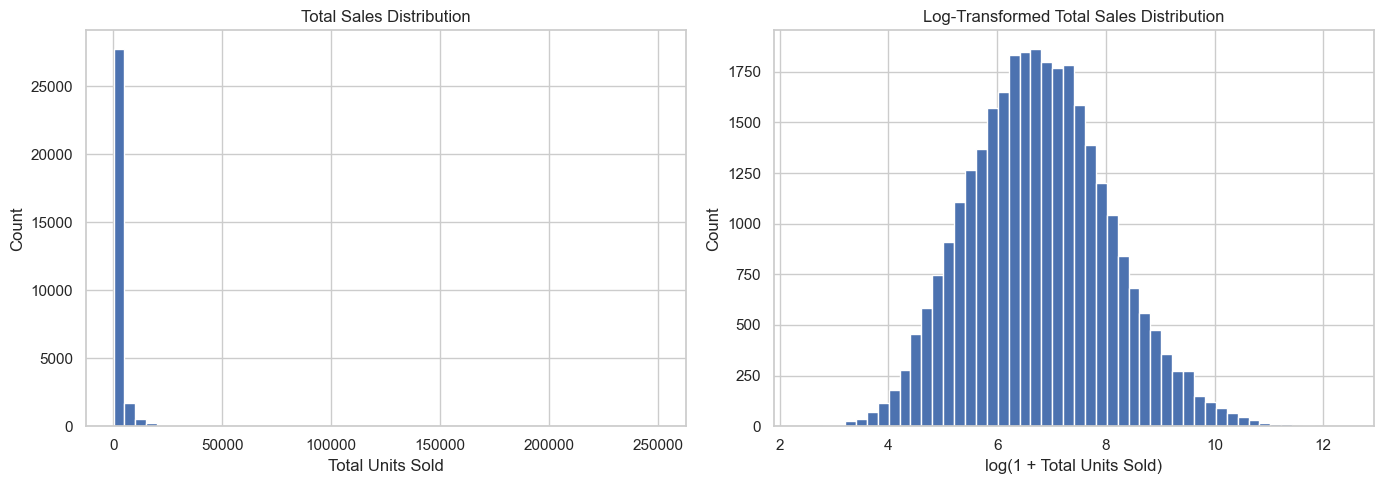

In [103]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original distribution
sales['total_sales'].hist(
    bins=50,
    ax=axes[0]
)

axes[0].set_title('Total Sales Distribution')
axes[0].set_xlabel('Total Units Sold')
axes[0].set_ylabel('Count')

# Log-transformed distribution
axes[1].hist(
    np.log1p(sales['total_sales']),
    bins=50
)

axes[1].set_title('Log-Transformed Total Sales Distribution')
axes[1].set_xlabel('log(1 + Total Units Sold)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

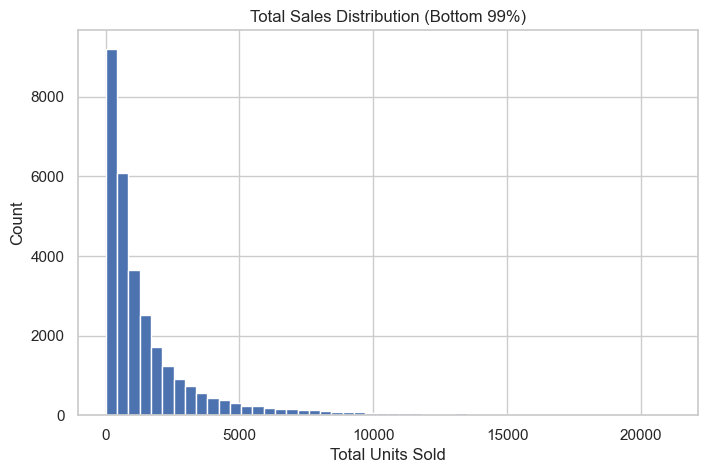

In [104]:
cutoff = sales['total_sales'].quantile(0.99)

plt.figure(figsize=(8,5))

sales.loc[
    sales['total_sales'] <= cutoff,
    'total_sales'
].hist(bins=50)

plt.title('Total Sales Distribution (Bottom 99%)')
plt.xlabel('Total Units Sold')
plt.ylabel('Count')

plt.show()

## A small number of products account for disproportionately large sales volumes.

In [105]:
#aggregate the products together to show total daily sales

daily_cols = [c for c in sales.columns if c.startswith("d_")]

daily_sales = sales[daily_cols].sum()

daily_sales.head()

d_1    32631
d_2    31749
d_3    23783
d_4    25412
d_5    19146
dtype: int64

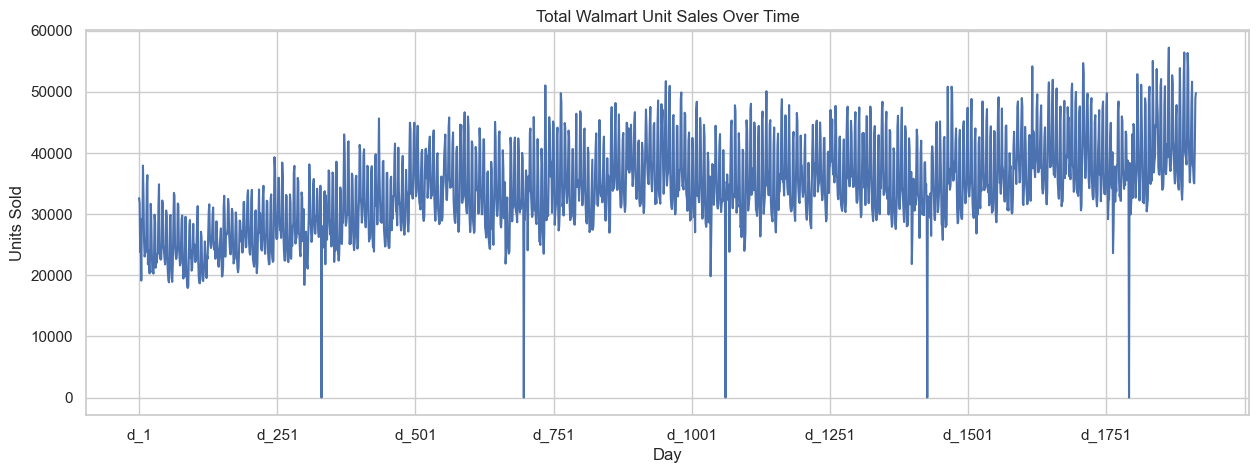

In [106]:
# plot total daily sales
plt.figure(figsize=(15,5))
daily_sales.plot()
plt.title("Total Walmart Unit Sales Over Time")
plt.xlabel("Day")
plt.ylabel("Units Sold")
plt.show()

In [107]:
# how many unique items exist per department?  

dept_counts = (
    sales.groupby(['cat_id', 'dept_id'])['item_id']
         .nunique()
         .reset_index(name='total_items')
)

dept_counts

,cat_id,dept_id,total_items
0,FOODS,FOODS_1,216
1,FOODS,FOODS_2,398
2,FOODS,FOODS_3,823
3,HOBBIES,HOBBIES_1,416
4,HOBBIES,HOBBIES_2,149
5,HOUSEHOLD,HOUSEHOLD_1,532
6,HOUSEHOLD,HOUSEHOLD_2,515


In [108]:
# how many units were sold total by department?

daily_cols = [c for c in sales.columns if c.startswith('d_')]

# Sum all sales within each department
dept_sales = (
    sales.groupby(['cat_id', 'dept_id'])[daily_cols]
         .sum()
         .sum(axis=1)
         .reset_index(name='total_units_sold')
)


dept_sales

,cat_id,dept_id,total_units_sold
0,FOODS,FOODS_1,5088041
1,FOODS,FOODS_2,7629822
2,FOODS,FOODS_3,32372076
3,HOBBIES,HOBBIES_1,5596460
4,HOBBIES,HOBBIES_2,528340
5,HOUSEHOLD,HOUSEHOLD_1,11500526
6,HOUSEHOLD,HOUSEHOLD_2,2980144


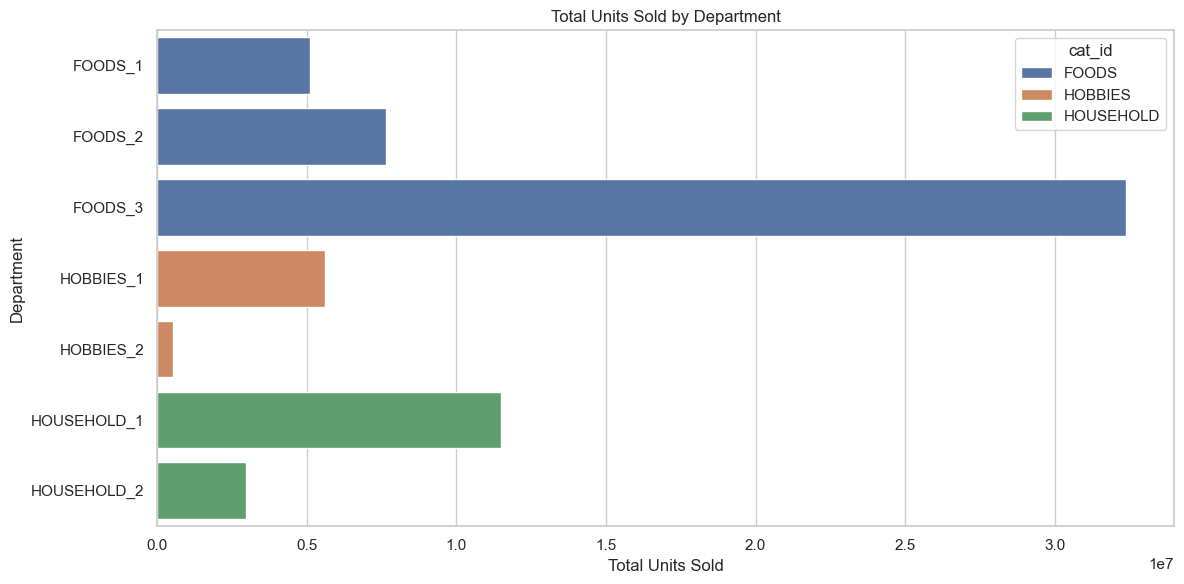

In [109]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=dept_sales,
    x='total_units_sold',
    y='dept_id',
    hue='cat_id'
)

plt.title('Total Units Sold by Department')
plt.xlabel('Total Units Sold')
plt.ylabel('Department')

plt.tight_layout()
plt.show()

In [110]:
# What percentage of total demand comes from each department?

dept_sales['pct_of_total'] = (
    dept_sales['total_units_sold']
    / dept_sales['total_units_sold'].sum()
    * 100
)

dept_sales['pct_total_sales'] = (
    dept_sales['total_units_sold']
    / dept_sales['total_units_sold'].sum()
    * 100
)

dept_sales[['dept_id', 'pct_total_sales']]

,dept_id,pct_total_sales
0,FOODS_1,7.744896
1,FOODS_2,11.613935
2,FOODS_3,49.276010
3,HOBBIES_1,8.518799
4,HOBBIES_2,0.804227
5,HOUSEHOLD_1,17.505829
6,HOUSEHOLD_2,4.536305


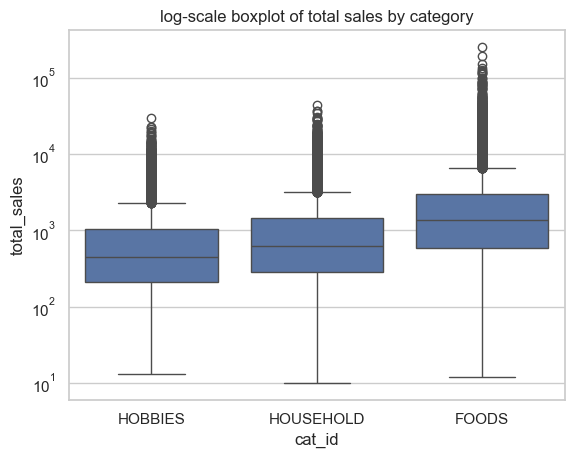

In [111]:
sns.boxplot(data=sales, x='cat_id', y='total_sales')
plt.yscale('log')
plt.title('log-scale boxplot of total sales by category')
plt.show()

In [112]:
# Get all daily sales columns
daily_cols = [c for c in sales.columns if c.startswith('d_')]

# Total sales across all products for each day
daily_sales = (
    sales[daily_cols]
    .sum(axis=0)
    .reset_index()
)

daily_sales.columns = ['d', 'total_sales']

# Merge with calendar events
daily_sales = daily_sales.merge(
    calendar[['d', 'event_type_1']],
    on='d',
    how='left'
)

daily_sales['event_type_1'] = (
    daily_sales['event_type_1']
    .fillna('No Event')
)

# Average sales by event type
event_sales = (
    daily_sales.groupby('event_type_1')['total_sales']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

event_sales

,event_type_1,total_sales
0,Sporting,35796.062500
1,No Event,34489.207504
2,Cultural,34234.742857
3,Religious,33760.692308
4,National,29458.509804


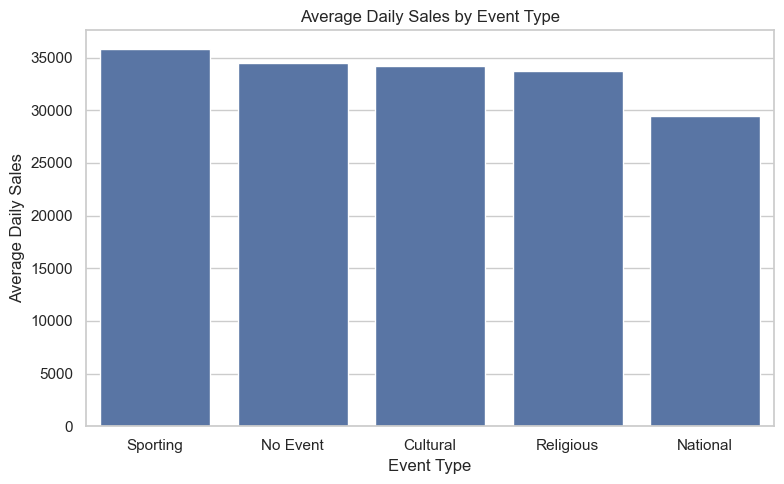

In [113]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=event_sales,
    x='event_type_1',
    y='total_sales'
)

plt.title('Average Daily Sales by Event Type')
plt.xlabel('Event Type')
plt.ylabel('Average Daily Sales')

plt.tight_layout()
plt.show()

# Sports = more sales; go Padres

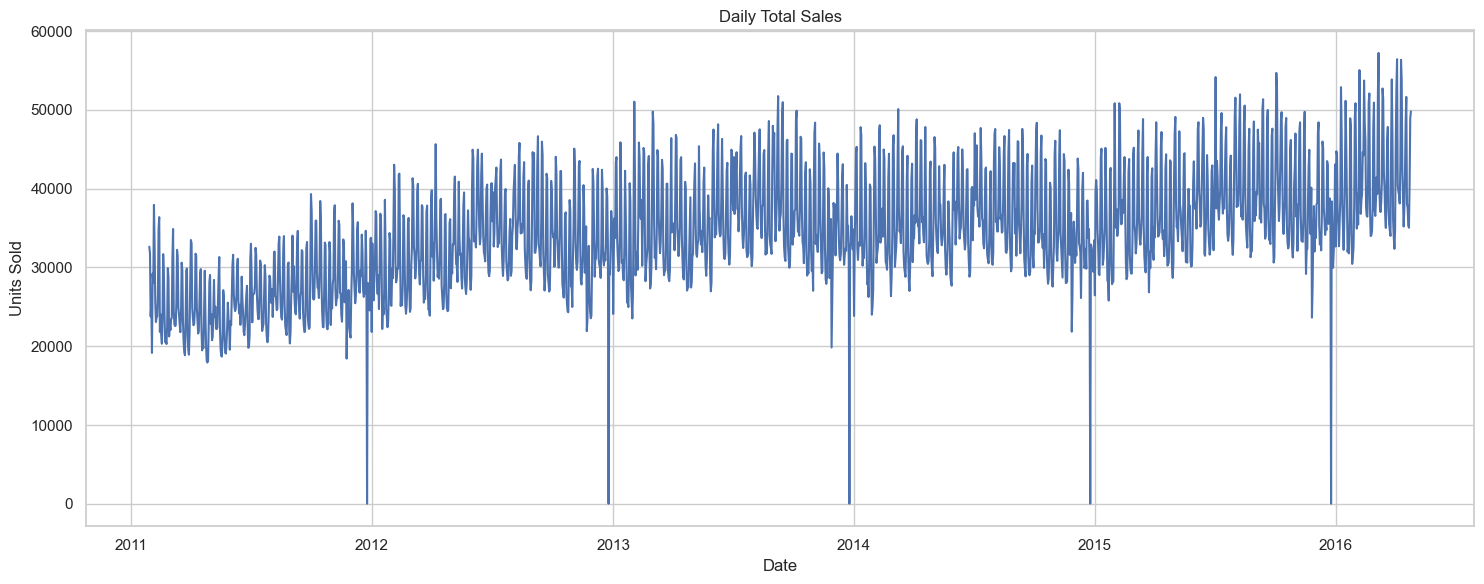

In [114]:
daily_cols = [c for c in sales.columns if c.startswith('d_')]

daily_sales = (
    sales[daily_cols]
    .sum(axis=0)
    .reset_index()
)

daily_sales.columns = ['d', 'total_sales']

daily_sales = daily_sales.merge(
    calendar[['d', 'date', 'event_name_1', 'event_type_1']],
    on='d',
    how='left'
)

plt.figure(figsize=(15,6))

plt.plot(
    pd.to_datetime(daily_sales['date']),
    daily_sales['total_sales']
)

plt.title('Daily Total Sales')
plt.xlabel('Date')
plt.ylabel('Units Sold')

plt.tight_layout()
plt.show()

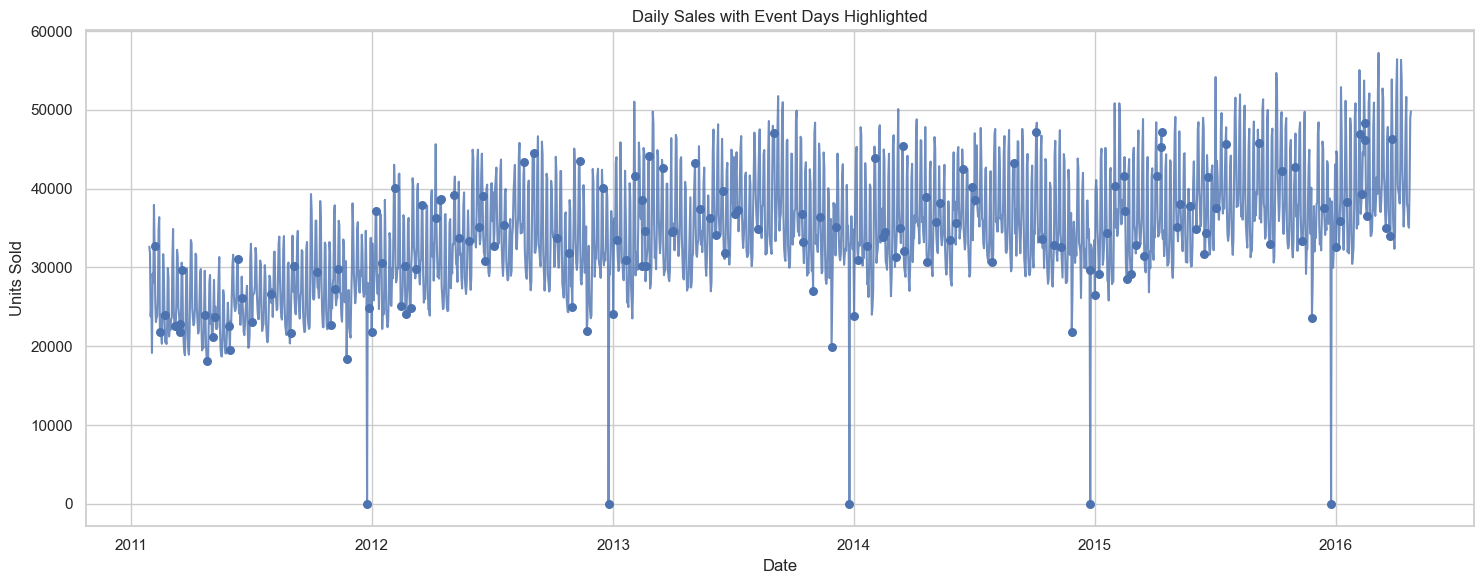

In [115]:
event_days = daily_sales[
    daily_sales['event_name_1'].notna()
]

plt.figure(figsize=(15,6))

plt.plot(
    pd.to_datetime(daily_sales['date']),
    daily_sales['total_sales'],
    alpha=0.8
)

plt.scatter(
    pd.to_datetime(event_days['date']),
    event_days['total_sales'],
    s=30
)

plt.title('Daily Sales with Event Days Highlighted')
plt.xlabel('Date')
plt.ylabel('Units Sold')

plt.tight_layout()
plt.show()

In [116]:
daily_sales.groupby(
    'event_name_1'
)['total_sales'].mean().sort_values(
    ascending=False
)

event_name_1
LaborDay               42154.600000
SuperBowl              40924.000000
Easter                 39517.600000
OrthodoxEaster         38277.000000
Father's day           36562.000000
Purim End              35957.000000
Eid al-Fitr            35267.600000
ColumbusDay            35164.800000
VeteransDay            35118.800000
Ramadan starts         34779.600000
EidAlAdha              34504.000000
PresidentsDay          34446.333333
Mother's day           34211.400000
IndependenceDay        33710.800000
NBAFinalsEnd           33564.200000
ValentinesDay          33495.666667
StPatricksDay          33459.666667
Pesach End             33450.200000
Chanukah End           33426.800000
MartinLutherKingDay    33378.600000
OrthodoxChristmas      33344.200000
Cinco De Mayo          32823.500000
MemorialDay            32699.600000
NBAFinalsStart         31874.400000
LentStart              30727.000000
Halloween              30059.400000
LentWeek2              29747.000000
NewYear        

In [117]:
daily_sales['event_flag'] = (
    daily_sales['event_name_1']
    .notna()
)

daily_sales.groupby('event_flag')['total_sales'].describe()

,count,mean,std,min,25%,50%,75%,max
event_flag,,,,,,,,
False,1759.0,34489.207504,7133.701801,17929.0,29702.0,33714.0,38752.5,57218.0
True,154.0,32655.149351,9300.905832,11.0,29180.5,33779.5,38494.5,48337.0


In [145]:
top_days = daily_sales.nlargest(
    60,
    'total_sales'
)

top_days[
    ['date',
     'total_sales',
     'event_name_1']
]

,date,total_sales,event_name_1
1863,2016-03-06,57218,NaN
1891,2016-04-03,56425,NaN
1897,2016-04-09,56340,NaN
1834,2016-02-06,55040,NaN
1708,2015-10-03,54687,NaN
1616,2015-07-03,54154,NaN
1883,2016-03-26,53863,NaN
1898,2016-04-10,53856,NaN
1841,2016-02-13,53715,NaN
1709,2015-10-04,52895,NaN


## The hypothesis that the biggest sales spikes are caused by labeled calendar events is not supported by data. 
## The presence of an event alone may not be a strong predictor of sales and that specific event types should be analyzed separately.

In [118]:
daily_sales = daily_sales.merge(
    calendar[['d', 'snap_CA']],
    on='d',
    how='left'
)

snap_summary = (
    daily_sales.groupby('snap_CA')['total_sales']
    .mean()
    .reset_index()
)

snap_summary

,snap_CA,total_sales
0,0,33408.506625
1,1,36241.738095


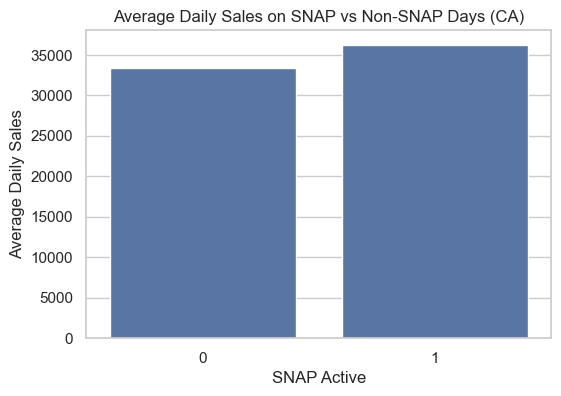

In [119]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=snap_summary,
    x='snap_CA',
    y='total_sales'
)

plt.title('Average Daily Sales on SNAP vs Non-SNAP Days (CA)')
plt.xlabel('SNAP Active')
plt.ylabel('Average Daily Sales')

plt.show()

In [120]:
daily_cols = [c for c in sales.columns if c.startswith('d_')]

daily_sales = (
    sales[daily_cols]
    .sum(axis=0)
    .reset_index()
)

daily_sales.columns = ['d', 'total_sales']

daily_sales = daily_sales.merge(
    calendar[
        [
            'd',
            'date',
            'event_name_1',
            'event_type_1',
            'snap_CA',
            'snap_TX',
            'snap_WI'
        ]
    ],
    on='d',
    how='left'
)

daily_sales['date'] = pd.to_datetime(daily_sales['date'])

for state in ['snap_CA', 'snap_TX', 'snap_WI']:
    print(
        state,
        daily_sales.groupby(state)['total_sales'].mean()
    )

snap_CA snap_CA
0    33408.506625
1    36241.738095
Name: total_sales, dtype: float64
snap_TX snap_TX
0    33263.012471
1    36538.038095
Name: total_sales, dtype: float64
snap_WI snap_WI
0    33239.736555
1    36585.439683
Name: total_sales, dtype: float64


## Analysis of SNAP eligibility indicators revealed consistently higher sales on SNAP days across all three states. Average daily sales increased by approximately 8.5% in California, 9.8% in Texas, and 10.1% in Wisconsin. This suggests that SNAP participation may be a meaningful predictor of consumer demand and should be considered during feature engineering and model development.

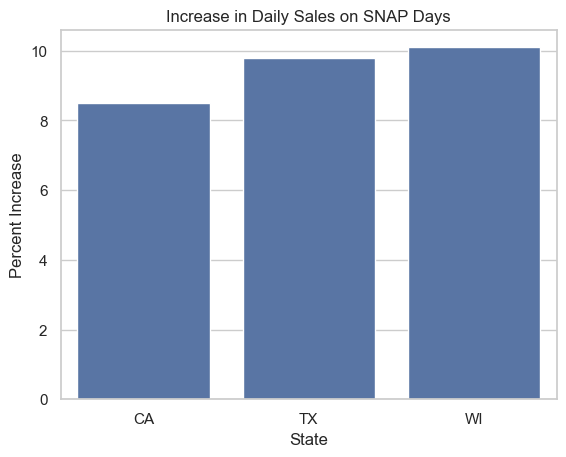

In [121]:
snap_effect = pd.DataFrame({
    'State': ['CA', 'TX', 'WI'],
    'Sales Increase (%)': [8.5, 9.8, 10.1]
})

sns.barplot(
    data=snap_effect,
    x='State',
    y='Sales Increase (%)'
)

plt.title('Increase in Daily Sales on SNAP Days')
plt.ylabel('Percent Increase')
plt.show()

Text(0, 0.5, 'Total Sales')

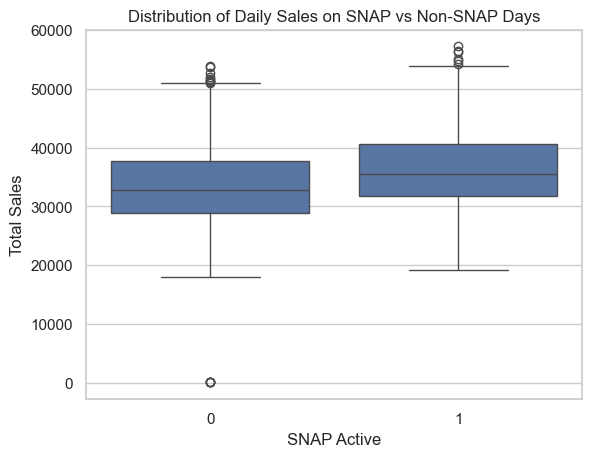

In [122]:
sns.boxplot(
    data=daily_sales,
    x='snap_CA',
    y='total_sales'
)

plt.title('Distribution of Daily Sales on SNAP vs Non-SNAP Days')
plt.xlabel('SNAP Active')
plt.ylabel('Total Sales')

In [123]:
snap_dates = daily_sales.loc[
    daily_sales['snap_CA'] == 1,
    'date'
]

daily_sales = daily_sales.sort_values('date').reset_index(drop=True)

windows = []

for snap_date in snap_dates:

    snap_idx = daily_sales.index[
        daily_sales['date'] == snap_date
    ][0]

    for offset in range(-7, 8):

        idx = snap_idx + offset

        if 0 <= idx < len(daily_sales):

            windows.append({
                'relative_day': offset,
                'sales': daily_sales.loc[idx, 'total_sales']
            })

snap_window = pd.DataFrame(windows)

snap_effect = (
    snap_window
    .groupby('relative_day')['sales']
    .mean()
    .reset_index()
)

snap_effect

,relative_day,sales
0,-7,33284.156550
1,-6,33761.944179
2,-5,34158.918790
3,-4,34671.251192
4,-3,35121.961905
5,-2,35570.334921
6,-1,36024.665079
7,0,36241.738095
8,1,36239.342857
9,2,36220.603175


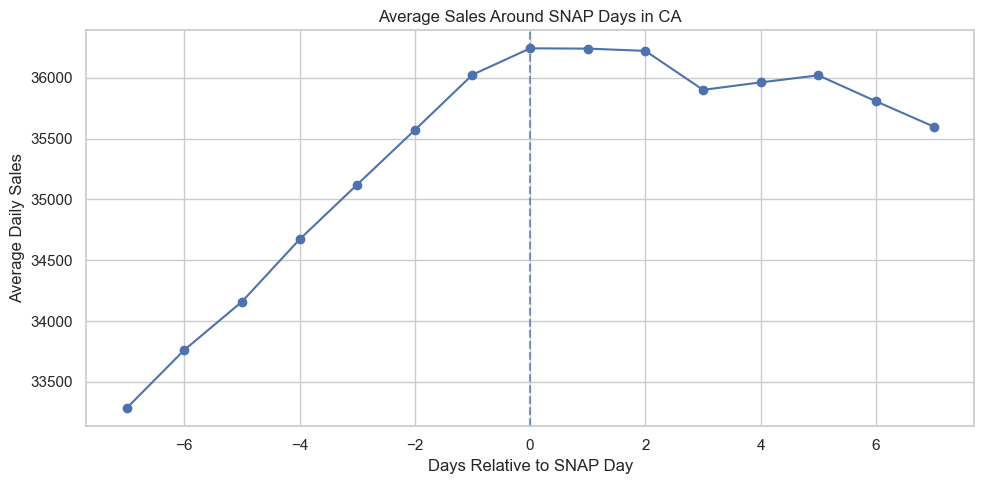

In [124]:
plt.figure(figsize=(10,5))

plt.plot(
    snap_effect['relative_day'],
    snap_effect['sales'],
    marker='o'
)

plt.axvline(
    x=0,
    linestyle='--',
    alpha=0.7
)

plt.title('Average Sales Around SNAP Days in CA')
plt.xlabel('Days Relative to SNAP Day')
plt.ylabel('Average Daily Sales')

plt.tight_layout()
plt.show()

## Sales steadily increase as you approach a SNAP day. Sales peak around day 0 to day +2. Sales remain elevated for several days afterward. The effect isn't just a one-day spike.

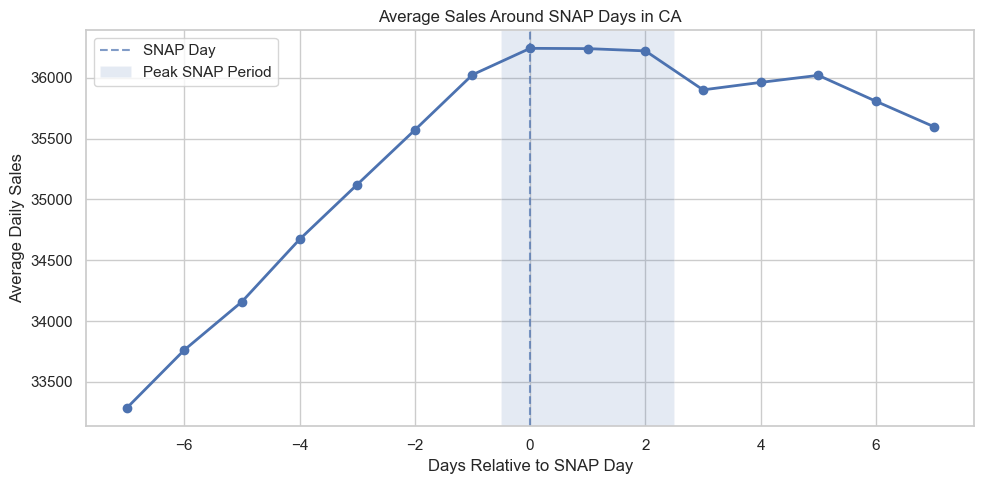

In [125]:
plt.figure(figsize=(10,5))

plt.plot(
    snap_effect['relative_day'],
    snap_effect['sales'],
    marker='o',
    linewidth=2
)

plt.axvline(
    x=0,
    linestyle='--',
    alpha=0.7,
    label='SNAP Day'
)

plt.axvspan(
    -0.5,
    2.5,
    alpha=0.15,
    label='Peak SNAP Period'
)

plt.title('Average Sales Around SNAP Days in CA')
plt.xlabel('Days Relative to SNAP Day')
plt.ylabel('Average Daily Sales')
plt.legend()

plt.tight_layout()
plt.show()

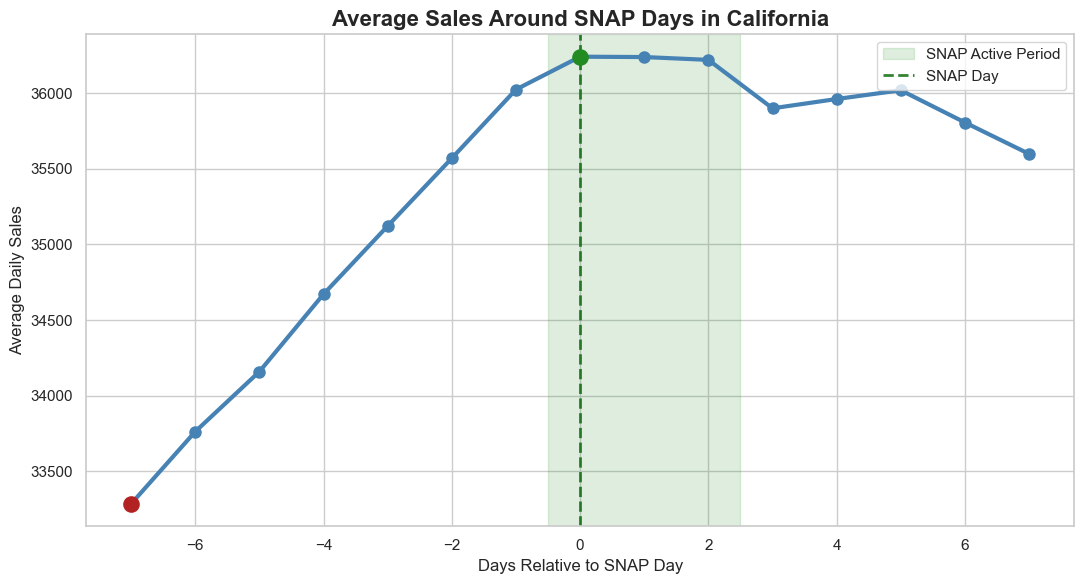

In [126]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(11, 6))

# Main line
plt.plot(
    snap_effect['relative_day'],
    snap_effect['sales'],
    marker='o',
    markersize=8,
    linewidth=3,
    color='steelblue'
)

# SNAP period shading
plt.axvspan(
    -0.5,
    2.5,
    color='forestgreen',
    alpha=0.15,
    label='SNAP Active Period'
)

# SNAP day marker
plt.axvline(
    x=0,
    color='darkgreen',
    linestyle='--',
    linewidth=2,
    alpha=0.8,
    label='SNAP Day'
)

peak_day = snap_effect.loc[
    snap_effect['sales'].idxmax(),
    'relative_day'
]

peak_sales = snap_effect['sales'].max()

baseline_sales = snap_effect.loc[
    snap_effect['relative_day'] == -7,
    'sales'
].iloc[0]

plt.scatter(
    peak_day,
    peak_sales,
    s=120,
    color='forestgreen',
    zorder=5
)


plt.scatter(
    -7,
    baseline_sales,
    s=120,
    color='firebrick',
    zorder=5
)


plt.title(
    'Average Sales Around SNAP Days in California',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel(
    'Days Relative to SNAP Day',
    fontsize=12
)

plt.ylabel(
    'Average Daily Sales',
    fontsize=12
)

plt.legend()
plt.tight_layout()
plt.show()

In [127]:
baseline = snap_effect.loc[
    snap_effect['relative_day'] == -7,
    'sales'
].iloc[0]

peak = snap_effect['sales'].max()

pct_increase = (peak - baseline) / baseline * 100

print(f"{pct_increase:.1f}%")

8.9%


## SNAP participation appears to have a meaningful relationship with consumer demand. Average daily sales were approximately 8–10% higher on SNAP days across all three states. A temporal analysis centered on SNAP days further revealed a consistent increase in sales leading up to and immediately following SNAP periods, with peak sales approximately 8.9% higher than baseline levels. These findings suggest that SNAP eligibility is an important demand driver and may provide predictive value in forecasting models.

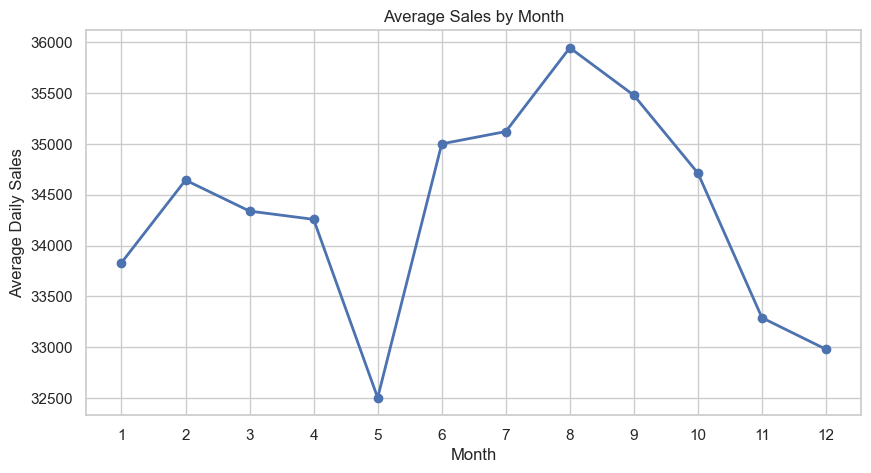

In [128]:
daily_sales['month_num'] = (
    pd.to_datetime(daily_sales['date'])
    .dt.month
)

monthly_sales = (
    daily_sales.groupby('month_num')['total_sales']
    .mean()
)

plt.figure(figsize=(10,5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker='o',
    linewidth=2
)

plt.title('Average Sales by Month')
plt.xlabel('Month')
plt.ylabel('Average Daily Sales')

plt.xticks(range(1,13))

plt.show()

## 

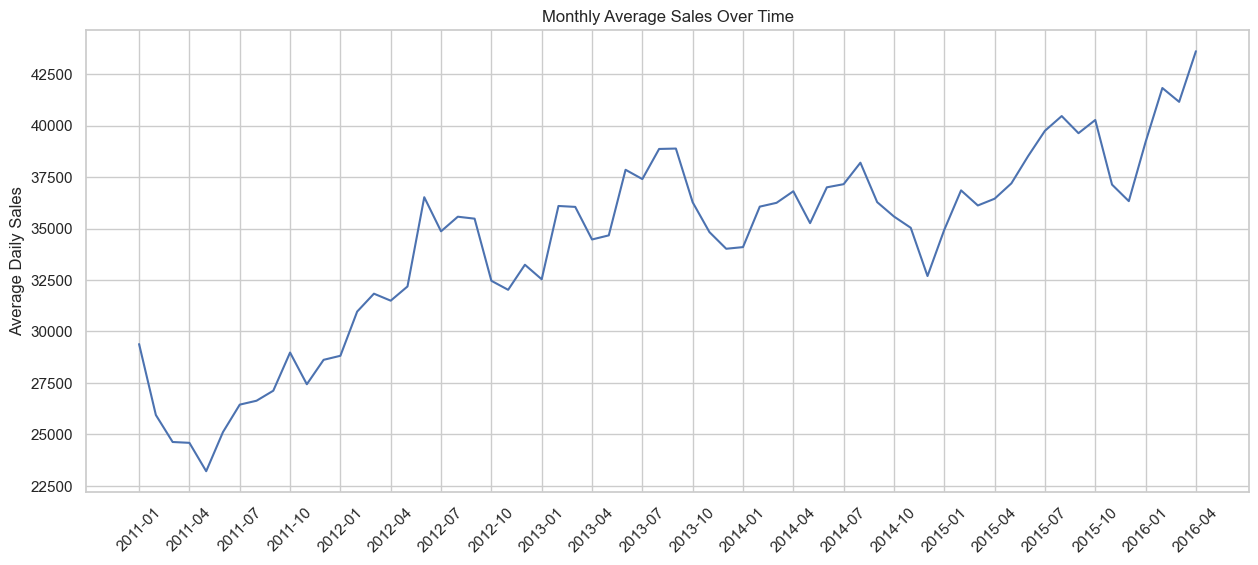

In [129]:
daily_sales['month'] = (
    pd.to_datetime(daily_sales['date'])
    .dt.to_period('M')
)

monthly_trend = (
    daily_sales.groupby('month')['total_sales']
    .mean()
    .reset_index()
)

monthly_trend['month'] = monthly_trend['month'].astype(str)

plt.figure(figsize=(15,6))

plt.plot(
    monthly_trend['month'],
    monthly_trend['total_sales']
)

plt.title('Monthly Average Sales Over Time')
plt.ylabel('Average Daily Sales')

plt.xticks(
    monthly_trend.index[::3],
    monthly_trend['month'][::3],
    rotation=45
)

plt.show()

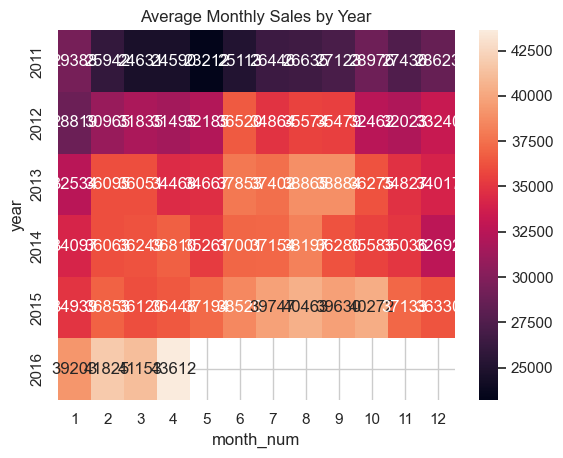

In [130]:
daily_sales['year'] = (
    pd.to_datetime(daily_sales['date'])
    .dt.year
)

daily_sales['month_num'] = (
    pd.to_datetime(daily_sales['date'])
    .dt.month
)

heatmap_data = (
    daily_sales.groupby(['year','month_num'])['total_sales']
    .mean()
    .unstack()
)

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.0f'
)

plt.title('Average Monthly Sales by Year')
plt.show()



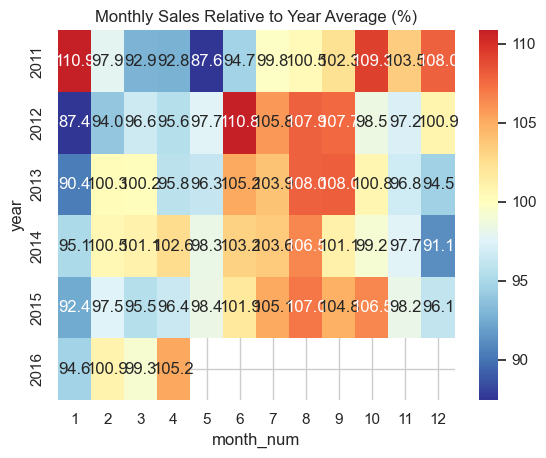

In [131]:
heatmap_pct = heatmap_data.div(
    heatmap_data.mean(axis=1),
    axis=0
) * 100

sns.heatmap(
    heatmap_pct,
    annot=True,
    fmt='.1f',
    center=100,
    cmap='RdYlBu_r'
)

plt.title('Monthly Sales Relative to Year Average (%)')
plt.show()

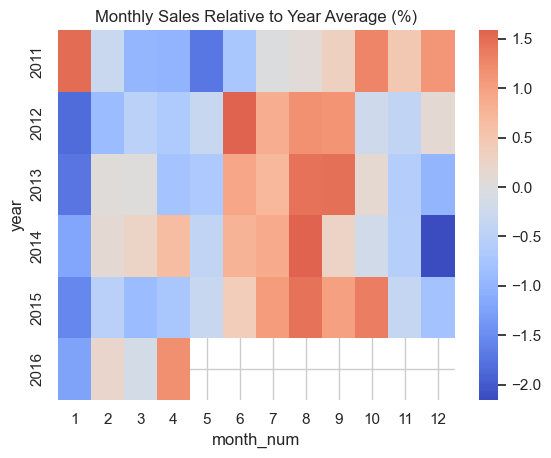

In [132]:
heatmap_z = (
    heatmap_data
    .sub(heatmap_data.mean(axis=1), axis=0)
    .div(heatmap_data.std(axis=1), axis=0)
)

sns.heatmap(
    heatmap_z,
    center=0,
    cmap='coolwarm'
)

plt.title('Monthly Sales Relative to Year Average (%)')
plt.show()

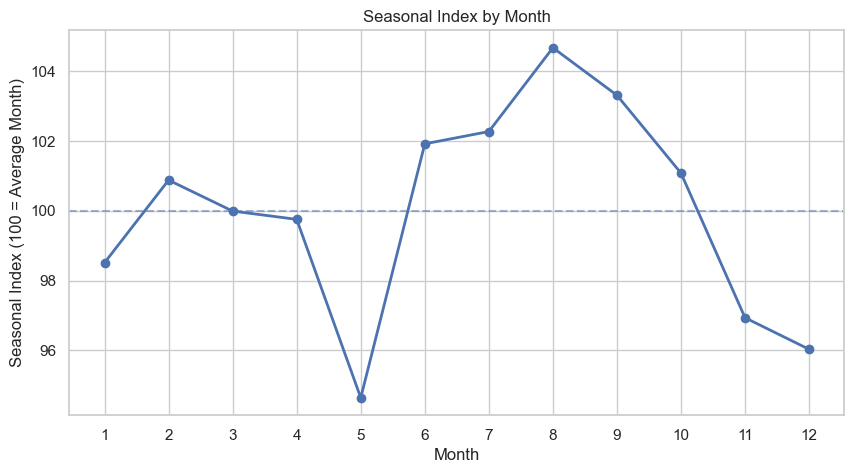

In [133]:
monthly_sales = (
    daily_sales.groupby(
        daily_sales['date'].dt.month
    )['total_sales']
    .mean()
)

seasonal_index = (
    monthly_sales /
    monthly_sales.mean()
    * 100
)

plt.figure(figsize=(10,5))

plt.plot(
    seasonal_index.index,
    seasonal_index.values,
    marker='o',
    linewidth=2
)

plt.axhline(
    100,
    linestyle='--',
    alpha=0.5
)

plt.title('Seasonal Index by Month')
plt.xlabel('Month')
plt.ylabel('Seasonal Index (100 = Average Month)')

plt.xticks(range(1,13))

plt.show()

## Monthly sales exhibit clear seasonality, with demand increasing during the summer months and peaking in August. Average daily sales during August were approximately 10% higher than those observed in May, the lowest-demand month. This pattern suggests that month-of-year may provide predictive value in forecasting models and should be considered during feature engineering.

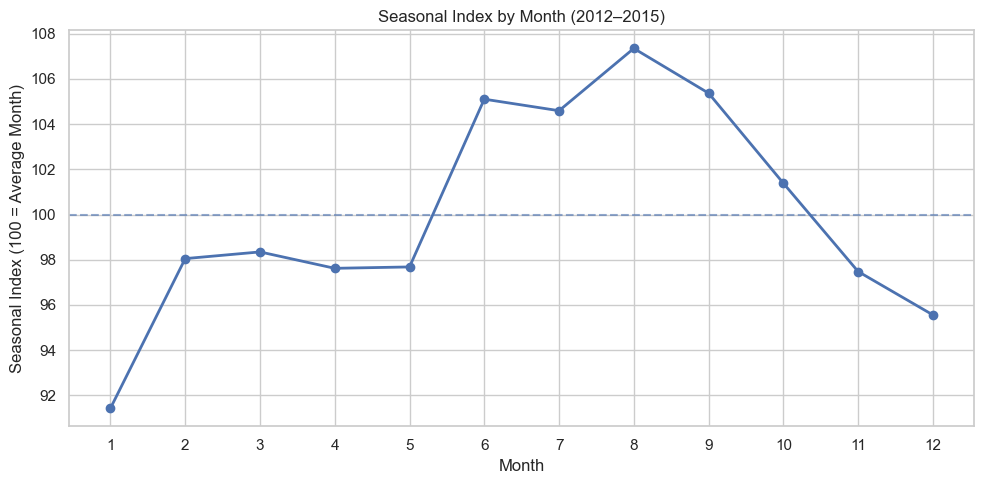

In [134]:
# Keep only complete years
seasonal_df = daily_sales[
    daily_sales['date'].dt.year.between(2012, 2015)
].copy()

# Average sales by month across 2012–2015
monthly_sales = (
    seasonal_df.groupby(
        seasonal_df['date'].dt.month
    )['total_sales']
    .mean()
)

# Create seasonal index
seasonal_index = (
    monthly_sales /
    monthly_sales.mean()
    * 100
)

# Plot
plt.figure(figsize=(10,5))

plt.plot(
    seasonal_index.index,
    seasonal_index.values,
    marker='o',
    linewidth=2
)

plt.axhline(
    100,
    linestyle='--',
    alpha=0.6
)

plt.title('Seasonal Index by Month (2012–2015)')
plt.xlabel('Month')
plt.ylabel('Seasonal Index (100 = Average Month)')

plt.xticks(range(1,13))

plt.tight_layout()
plt.show()

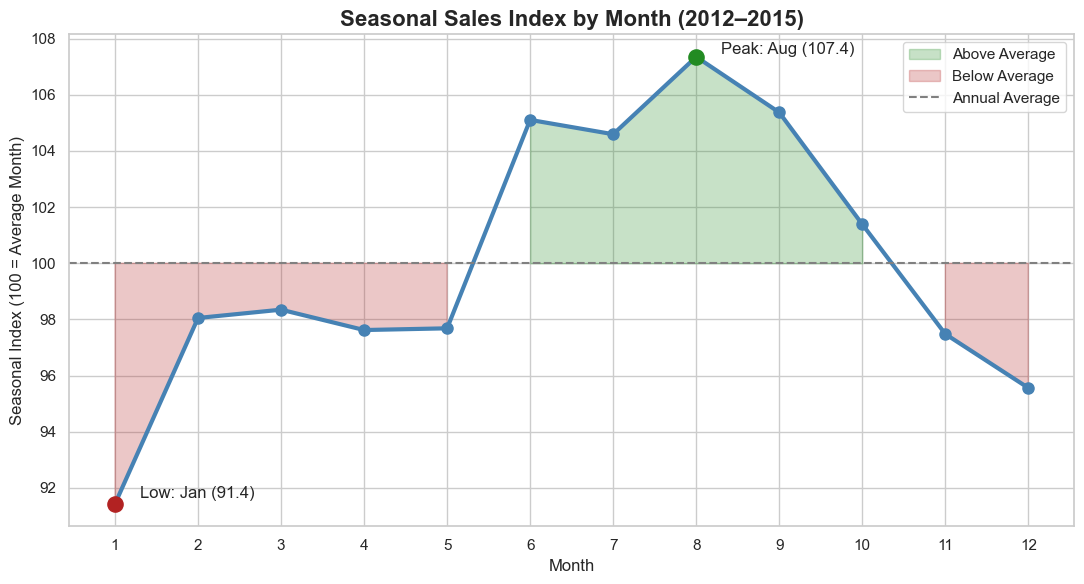

In [135]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(11, 6))

plt.plot(
    seasonal_index.index,
    seasonal_index.values,
    marker='o',
    markersize=8,
    linewidth=3,
    color='steelblue'
)

# Fill above/below average
plt.fill_between(
    seasonal_index.index,
    seasonal_index.values,
    100,
    where=seasonal_index.values >= 100,
    alpha=0.25,
    color='forestgreen',
    label='Above Average'
)

plt.fill_between(
    seasonal_index.index,
    seasonal_index.values,
    100,
    where=seasonal_index.values < 100,
    alpha=0.25,
    color='firebrick',
    label='Below Average'
)

# Average line
plt.axhline(
    y=100,
    color='gray',
    linestyle='--',
    linewidth=1.5,
    label='Annual Average'
)

# Highlight peak and trough
peak_month = seasonal_index.idxmax()
peak_value = seasonal_index.max()

low_month = seasonal_index.idxmin()
low_value = seasonal_index.min()

plt.scatter(
    peak_month,
    peak_value,
    s=120,
    color='forestgreen',
    zorder=5
)

plt.scatter(
    low_month,
    low_value,
    s=120,
    color='firebrick',
    zorder=5
)

plt.annotate(
    f'Peak: Aug ({peak_value:.1f})',
    (peak_month, peak_value),
    xytext=(peak_month + 0.3, peak_value + 0.1)
)

plt.annotate(
    f'Low: Jan ({low_value:.1f})',
    (low_month, low_value),
    xytext=(low_month + 0.3, low_value + 0.2)
)

plt.title(
    'Seasonal Sales Index by Month (2012–2015)',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Month', fontsize=12)
plt.ylabel('Seasonal Index (100 = Average Month)', fontsize=12)

plt.xticks(range(1, 13))

plt.legend()
plt.tight_layout()
plt.show()

## *those heatmaps made me look closer at 2011 and 2016 and I wonder if the time frame of the data that we use for analysis should be reduced to 2012-2015*

## After removing 2011 and 2016:
## Cleaner trends:
## Average daily sales in August are approximately 17% higher than in January.
## Seasonal demand patterns become more pronounced when only complete years (2012–2015) are analyzed. Sales are consistently strongest during the summer months, peaking in August at approximately 107% of the average monthly demand. In contrast, January exhibits the weakest demand at approximately 92% of average levels. This indicates a seasonal swing of roughly 17% between peak and low-demand periods, suggesting that month-of-year should be included as a forecasting feature.

## Summary of findings so far:
## 1. SNAP days increase sales by roughly 9%.
## 2. Summer demand is about 15–17% higher than winter demand.

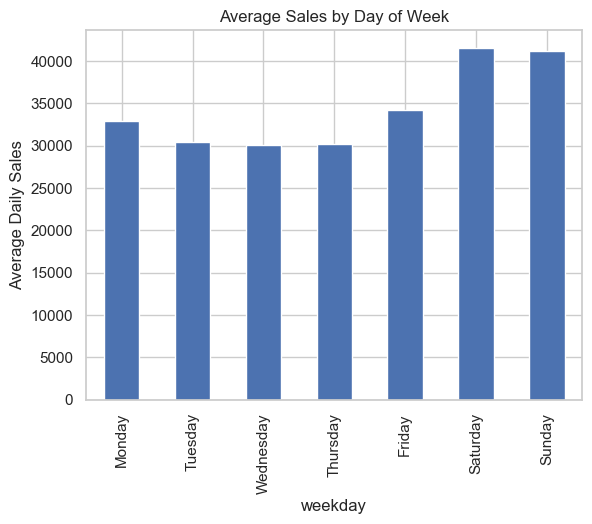

In [136]:
daily_sales = daily_sales.merge(
    calendar[['d', 'weekday']],
    on='d',
    how='left'
)

weekday_sales = (
    daily_sales.groupby('weekday')['total_sales']
    .mean()
    .reindex([
        'Monday',
        'Tuesday',
        'Wednesday',
        'Thursday',
        'Friday',
        'Saturday',
        'Sunday'
    ])
)

weekday_sales.plot(kind='bar')
plt.title('Average Sales by Day of Week')
plt.ylabel('Average Daily Sales')
plt.show()

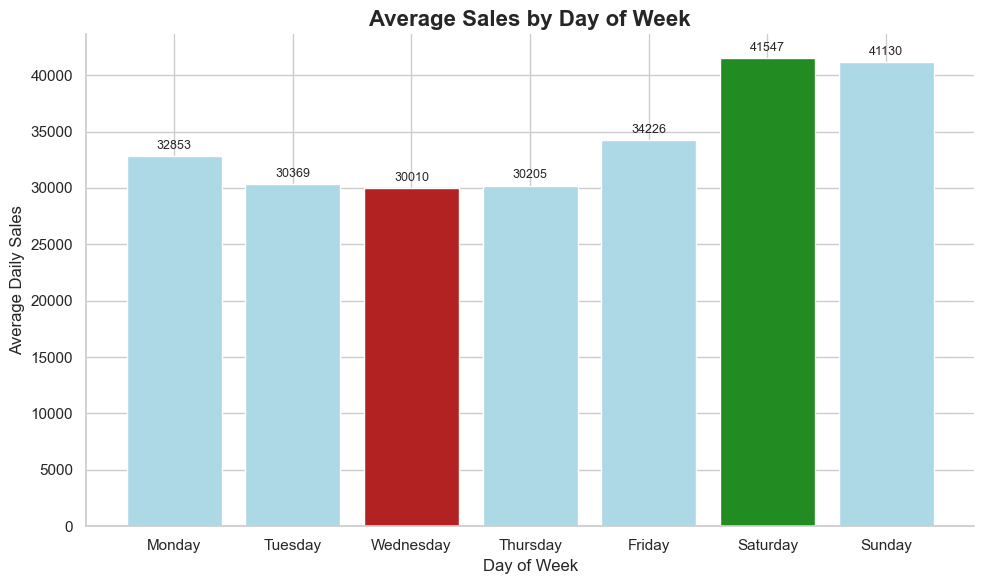

In [137]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

max_day = weekday_sales.idxmax()
min_day = weekday_sales.idxmin()

colors = [
    'forestgreen' if day == max_day
    else 'firebrick' if day == min_day
    else 'lightblue'
    for day in weekday_sales.index
]

bars = plt.bar(
    weekday_sales.index,
    weekday_sales.values,
    color=colors
)

plt.bar_label(
    bars,
    fmt='%.0f',
    padding=3,
    fontsize=9
)

plt.title(
    'Average Sales by Day of Week',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Day of Week')
plt.ylabel('Average Daily Sales')

sns.despine()

plt.tight_layout()
plt.show()

## Average daily sales are relatively stable Monday through Thursday, ranging from approximately 30,000 to 33,000 units. Sales begin increasing on Friday (34,226 units) and peak on Saturday (41,547 units), which is approximately 38% higher than Wednesday, the lowest-sales day (30,010 units). Sunday sales remain elevated at 41,130 units, indicating a strong weekend purchasing pattern. These results suggest that day-of-week is an important temporal feature and should be considered in forecasting models.

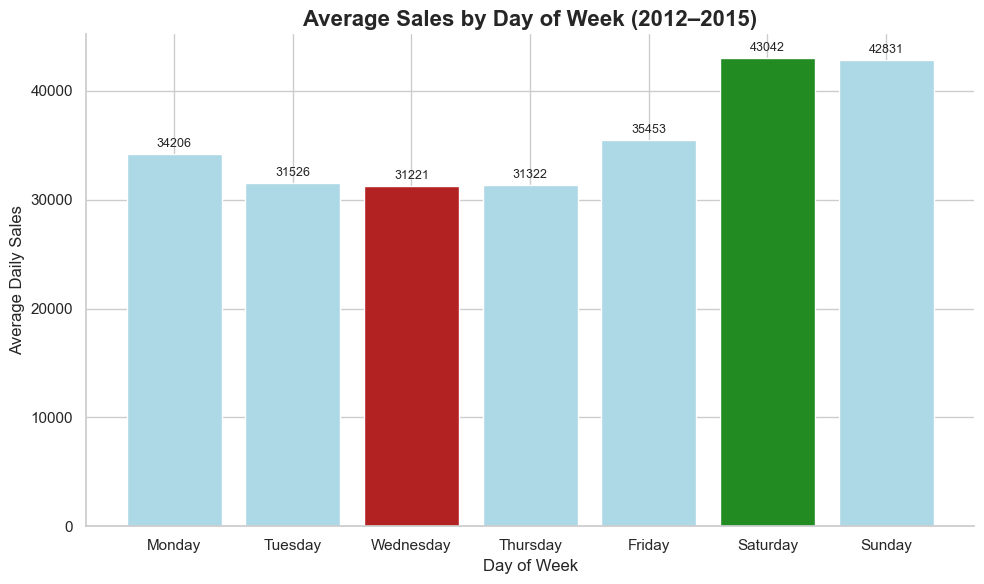

In [138]:
# Keep only complete years
weekday_df = daily_sales[
    daily_sales['date'].dt.year.between(2012, 2015)
].copy()

# Recalculate weekday averages
weekday_sales = (
    weekday_df.groupby('weekday')['total_sales']
    .mean()
    .reindex([
        'Monday',
        'Tuesday',
        'Wednesday',
        'Thursday',
        'Friday',
        'Saturday',
        'Sunday'
    ])
)

# Find highest and lowest days
max_day = weekday_sales.idxmax()
min_day = weekday_sales.idxmin()

# Plot
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

colors = [
    'forestgreen' if day == max_day
    else 'firebrick' if day == min_day
    else 'lightblue'
    for day in weekday_sales.index
]

bars = plt.bar(
    weekday_sales.index,
    weekday_sales.values,
    color=colors
)

plt.bar_label(
    bars,
    fmt='%.0f',
    padding=3,
    fontsize=9
)

plt.title(
    'Average Sales by Day of Week (2012–2015)',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Day of Week')
plt.ylabel('Average Daily Sales')

sns.despine()

plt.tight_layout()
plt.show()

## 2011 and 2016 do not have an effect on weekly trends

Text(0, 0.5, 'Count')

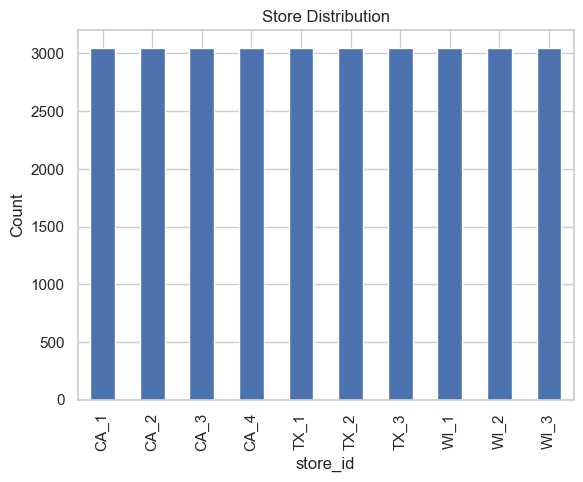

In [139]:
sales['store_id'].value_counts().sort_index().plot(kind='bar')
plt.title('Store Distribution')
plt.ylabel('Count')

Text(0, 0.5, 'Count')

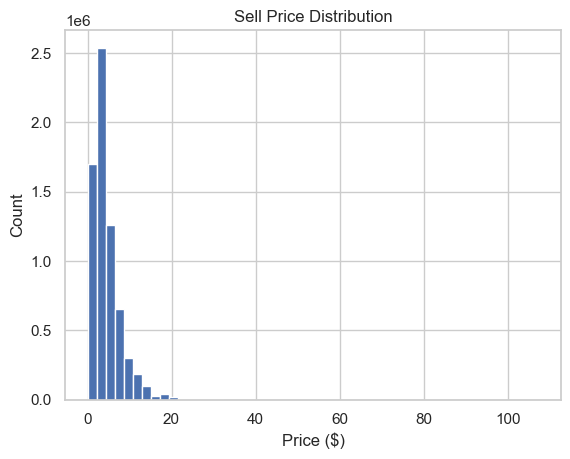

In [140]:
prices['sell_price'].hist(bins=50)
plt.title('Sell Price Distribution')
plt.xlabel('Price ($)')
plt.ylabel('Count')

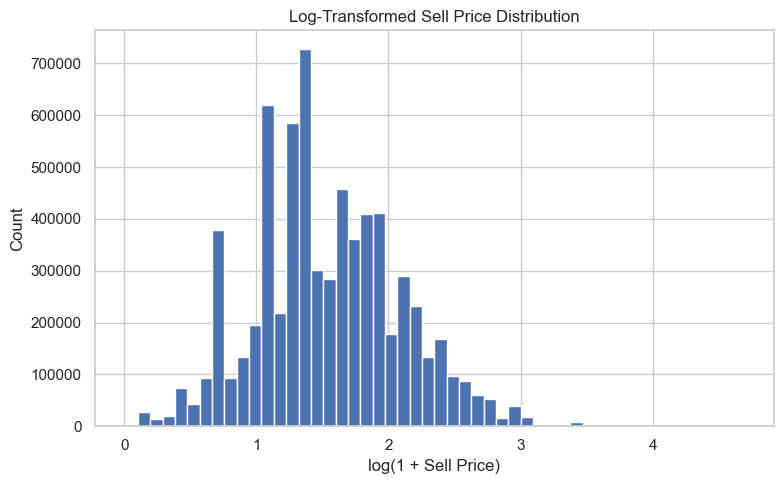

In [141]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    np.log1p(prices['sell_price']),
    bins=50
)

plt.title('Log-Transformed Sell Price Distribution')
plt.xlabel('log(1 + Sell Price)')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

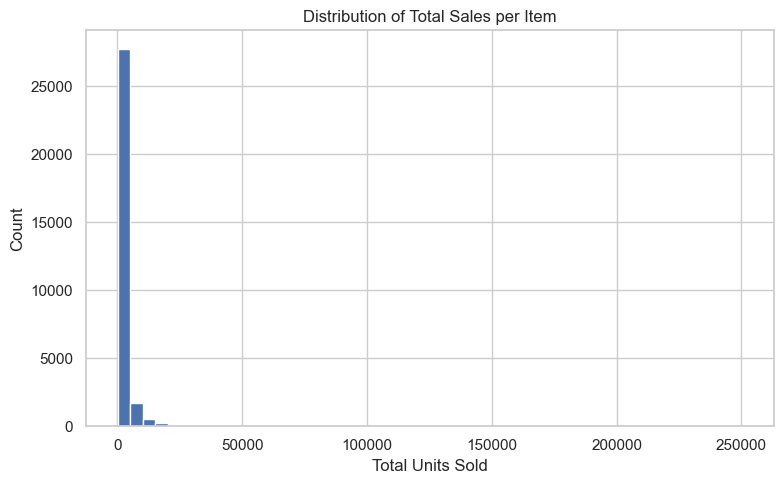

In [142]:
plt.figure(figsize=(8,5))

sales['total_sales'].hist(
    bins=50
)

plt.title('Distribution of Total Sales per Item')
plt.xlabel('Total Units Sold')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

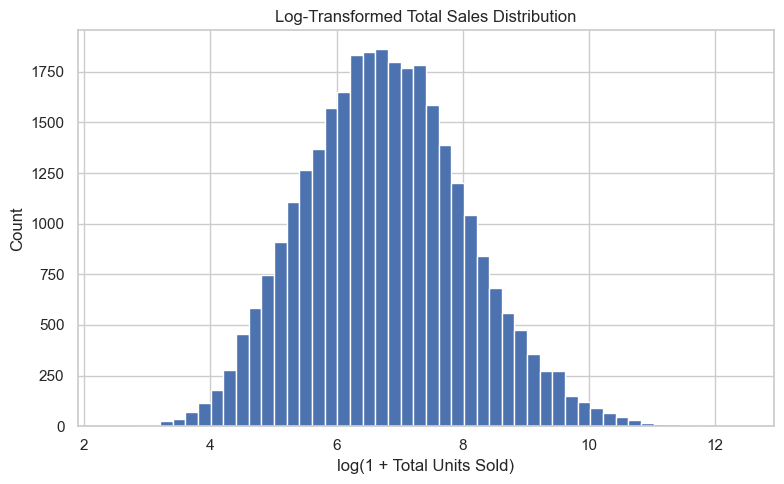

In [143]:
plt.figure(figsize=(8,5))

plt.hist(
    np.log1p(sales['total_sales']),
    bins=50
)

plt.title('Log-Transformed Total Sales Distribution')
plt.xlabel('log(1 + Total Units Sold)')
plt.ylabel('Count')

plt.tight_layout()
plt.show()